In [1]:
import numpy as np
from matplotlib import pyplot as plt
import ANNarchy as ann
from tvb_multiscale.tvb_annarchy.annarchy.models import Izhikevich_Hamker, Izhikevich_Hamker_Proxy_E

TEST = "CURRENT" # "CURRENT" # "RATE"

/home/docker/venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ANNarchy 5.0 (5.0.1) on linux (posix).


In [2]:
DT = 0.005
DT_RATIO = 2
TVB_DT = DT_RATIO*DT
Tsync = 1.16
Nsync = int(Tsync/TVB_DT)
print("Tsync = %g ms" % Tsync)
print("Nsync = %d TVB time steps" % Nsync)


Tsync = 1.16 ms
Nsync = 115 TVB time steps


In [3]:
net = ann.Network(dt=DT)

if TEST == "CURRENT":
    geometry = 600
    
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((Nsync, geometry)), geometry=geometry)) # CORRECT with warning for geometry!
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((Nsync, geometry)), schedule=0.0, geometry=(geometry,)))  # CORRECT
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((Nsync, geometry)), schedule=np.arange(115)*0.01, geometry=(geometry,)))  # CORRECT
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((1, geometry)), geometry=(geometry,)))  # CORRECT
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((1, 1)), geometry=(geometry,)))  # CORRECT with warning for geometry!
    inp = net.create(ann.TimedArray(rates=1.0*np.zeros((1, geometry)))) # CORRECT (the minimal correct)
    # inp = net.create(ann.TimedArray(rates=1.0*np.zeros((1, 1))))  # WRONG: error when trying to connect with CurrentInjection...
    proxy = net.create(geometry, neuron=Izhikevich_Hamker_Proxy_E)
    neuron = net.create(geometry, neuron=Izhikevich_Hamker)
    
    inp_to_proxy = net.connect(ann.CurrentInjection(inp, proxy, "ampa"))
    inp_to_proxy.connect_current()
    
    proxy_to_neuron = net.connect(proxy, neuron, "ampa")
    proxy_to_neuron.connect_fixed_probability(probability=0.1, weights=0.025)
    
    mP = net.monitor(proxy, ['g_ampa', 'spike'], period=1.0)
    mI = net.monitor(inp, 'r', period=1.0)
else:
    geometry = 100
    
    inp = net.create(ann.TimedPoissonPopulation(geometry, np.zeros((geometry, 1)).T, np.zeros((1,))))
    neuron = net.create(geometry, neuron=Izhikevich_Hamker)
    
    inp_to_neuron = net.connect(inp, neuron, "ampa")
    inp_to_neuron.connect_fixed_probability(probability=0.1, weights=0.25)
    
    mI = net.monitor(inp, ['r', 'spike'])

mN = net.monitor(neuron, ['g_ampa', 'spike'], period=1.0)

In [4]:
net.compile()

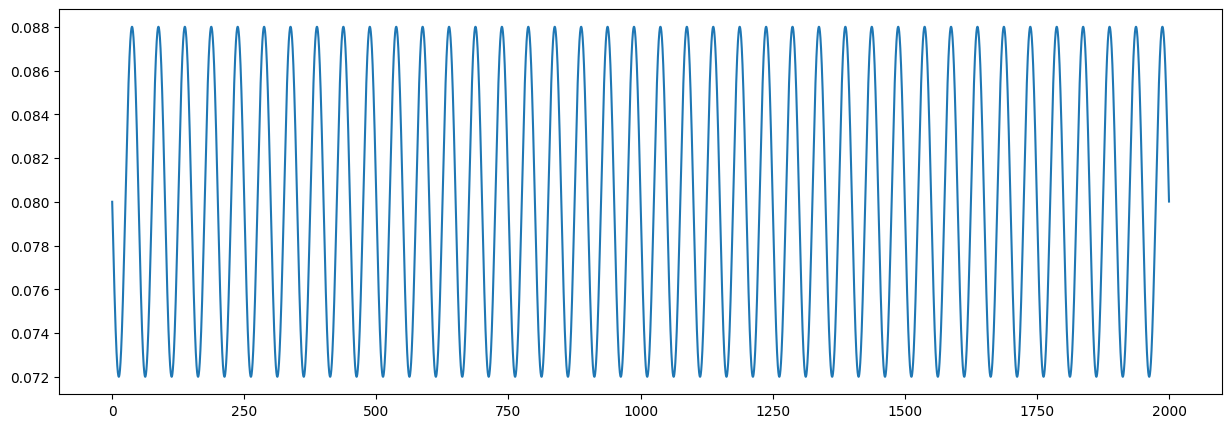

In [5]:
T = 2 * 1000.0 # ms
f = 20.0 / 1000  
omega = 2 *np.pi * f
time = np.arange(0.0, T, TVB_DT)
if TEST == "CURRENT":
    r0 = 0.08
    amplratio = 0.1
else:
    r0 = 12.0
    amplratio = 1.0
rates = r0 * (1 - amplratio*np.sin(time*omega))
plt.figure(figsize=(15, 5))
plt.plot(time, rates)
rates = rates[:, np.newaxis] * np.ones((1, geometry))
schedule = time


In [6]:
t = 0.0
while t <= T-Tsync:
    it = int(t/TVB_DT)
    if TEST == "RATE":
        inp.update(rates[it:it+Nsync], schedule[it:it+Nsync])
    else:
        # TODO: Find out why TimedArray gives an error if update() is used!
        inp.rates = rates[it:it+Nsync]
        print("time = %g" % net.time)
        print("TimedArray.schedule.shape = %s" % str(np.array(inp.schedule).shape))
        print("TimedArray.schedule = [%g, %g]" % (inp.schedule[0], inp.schedule[-1]))
        inp.schedule = schedule[it:it+Nsync]
        print("TimedArray.schedule.shape = %s" % str(np.array(inp.schedule).shape))
        print("TimedArray.schedule = [%g, %g]" % (inp.schedule[0], inp.schedule[-1]))
    net.simulate(Tsync)
    # t += Tsync
    t = net.time
    
# inp.update(rates, schedule)
# ann.simulate(T)

time = 0
TimedArray.schedule.shape = (1,)
TimedArray.schedule = [0, 0]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [0, 1.14]
time = 1.16
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [0, 1.14]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [1.15, 2.29]
time = 2.32
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [1.15, 2.29]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [2.31, 3.45]
time = 3.48
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [2.31, 3.45]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [3.48, 4.62]
time = 4.64
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [3.48, 4.62]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [4.63, 5.77]
time = 5.8
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [4.63, 5.77]
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [5.8, 6.94]
time = 6.96
TimedArray.schedule.shape = (115,)
TimedArray.schedule = [5.8, 6.94]
TimedArray.schedule.shape 

In [7]:
def get_plot_spikes(m, smooth=10.0):
    spikes = m.get('spike')
    spike_times, ranks = m.raster_plot(spikes)
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    axes[0].plot(spike_times, ranks, '.')
    axes[0].set_title("spikes")
    axes[0].set_ylabel("neuron")
    rates = m.population_rate(spikes, smooth=smooth)
    time = np.linspace(0, net.time, len(rates))
    axes[1].plot(time, rates)
    axes[1].set_title("r (smooth=%g ms)" % smooth)
    axes[1].set_xlabel("time")
    isi = m.inter_spike_interval(spikes)
    axes[2].hist(isi, bins=np.linspace(0, 200, 101))
    axes[2].set_title("ISI")
    axes[2].set_xlabel("time (ms)")
    # axes[1].set_ylim([0.0, 50.0])
    return spike_times, ranks, spikes, isi, m, fig, axes


def get_plot_vars(m, vrs=["r", "g_ampa"]):
    times = m.times()
    outputs = {}
    ts = {}
    fig, axes = plt.subplots(len(vrs), 1, figsize=(15, 6))
    if len(vrs) == 1:
        axes = [axes]
    for iV, var in enumerate(vrs):
        outputs[var] = m.get(var)
        ts[var] = np.linspace(times[var]["start"][0], net.time, len(outputs[var]))
        axes[iV].plot(ts[var], outputs[var])
        axes[iV].set_title(var)
    axes[-1].set_xlabel("time")
    fig.show()
    return outputs, ts, m, fig, axes




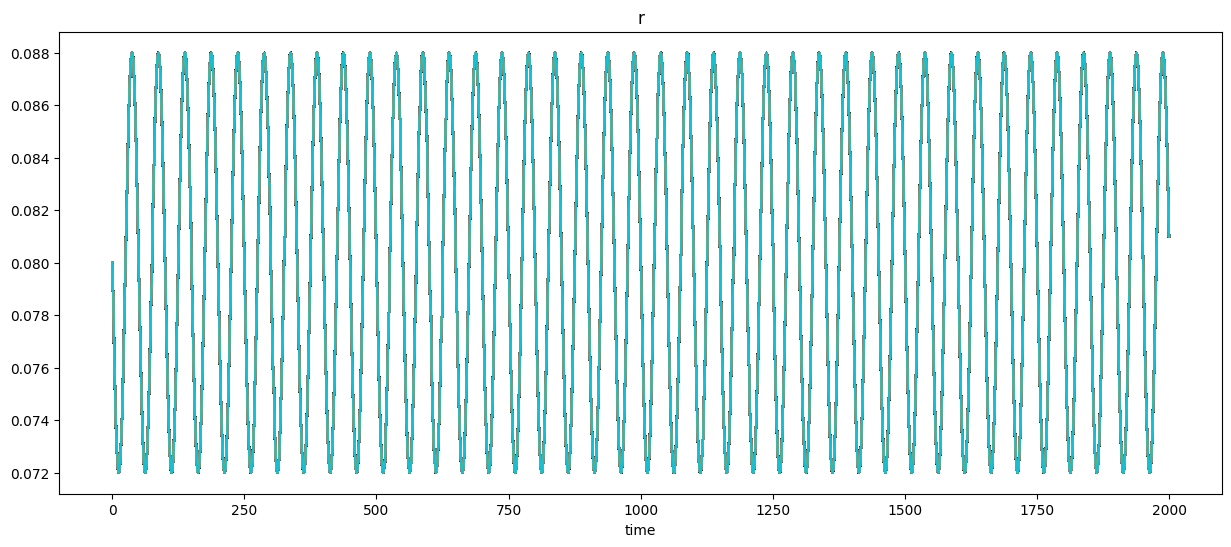

In [8]:
outputsI, tsI, mi, figI, axesI = get_plot_vars(mI, vrs=["r"])

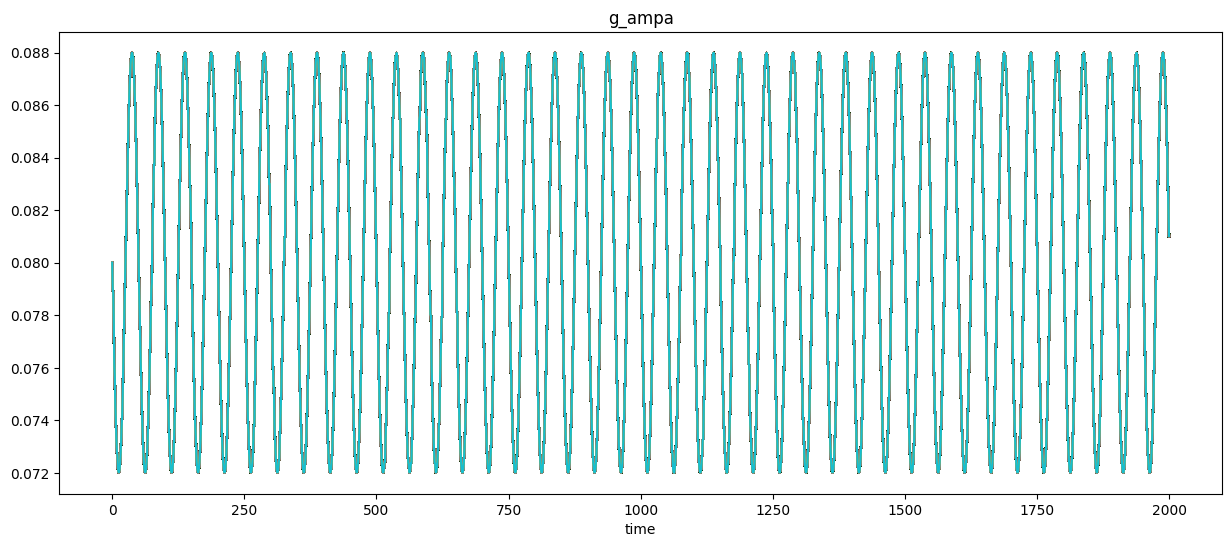

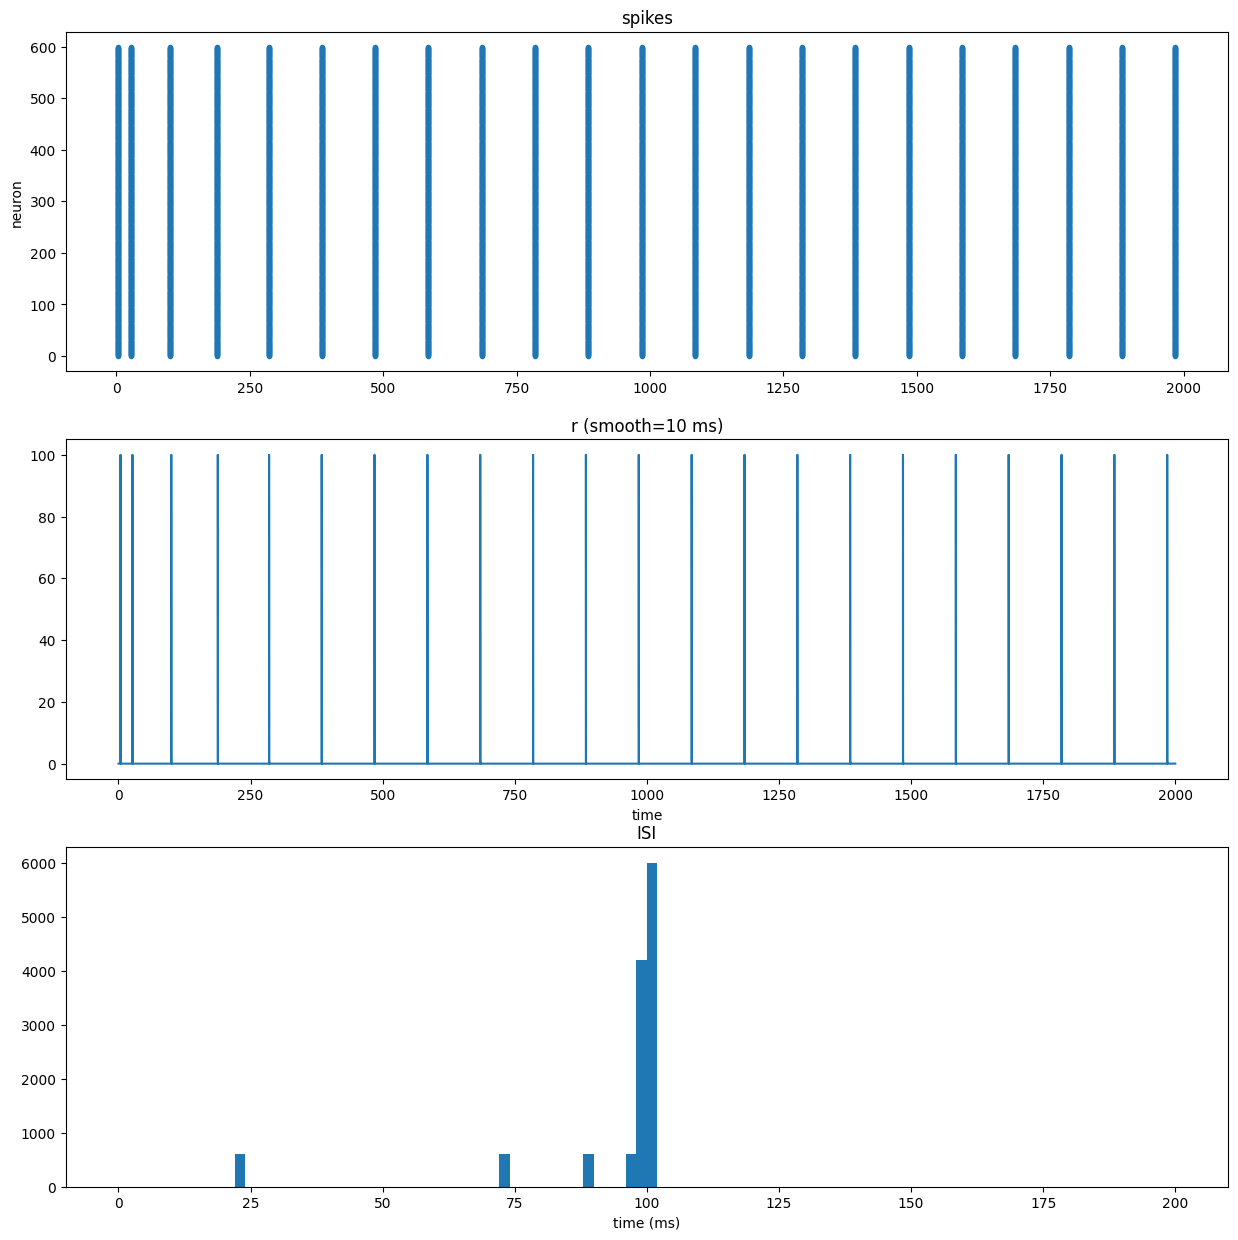

In [9]:
if TEST == "CURRENT":
    outputsP, tsP, mP, figP, axesP  = get_plot_vars(mP, vrs=["g_ampa"])
    spike_timesP, ranksP, spikesP, isiP, mP, figPsp, axesPsp = get_plot_spikes(mP)
else:
    spike_timesI, ranksI, spikesI, isiI, mI, figIsp, axesIsp = get_plot_spikes(mI)

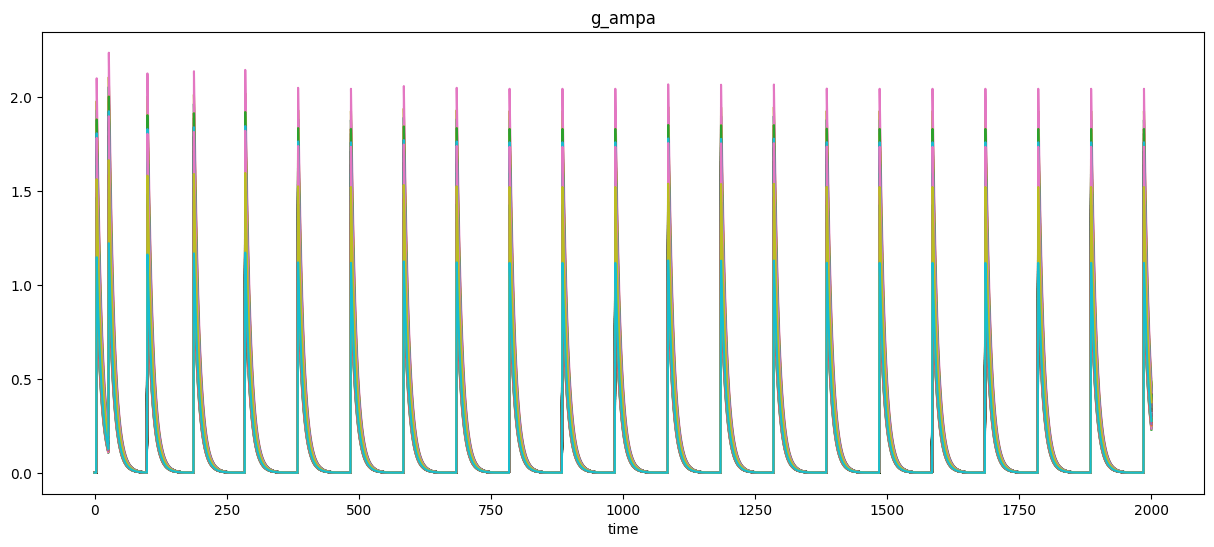

In [10]:
outputsN, tsN, mN, figN, axesN  = get_plot_vars(mN, vrs=["g_ampa"])

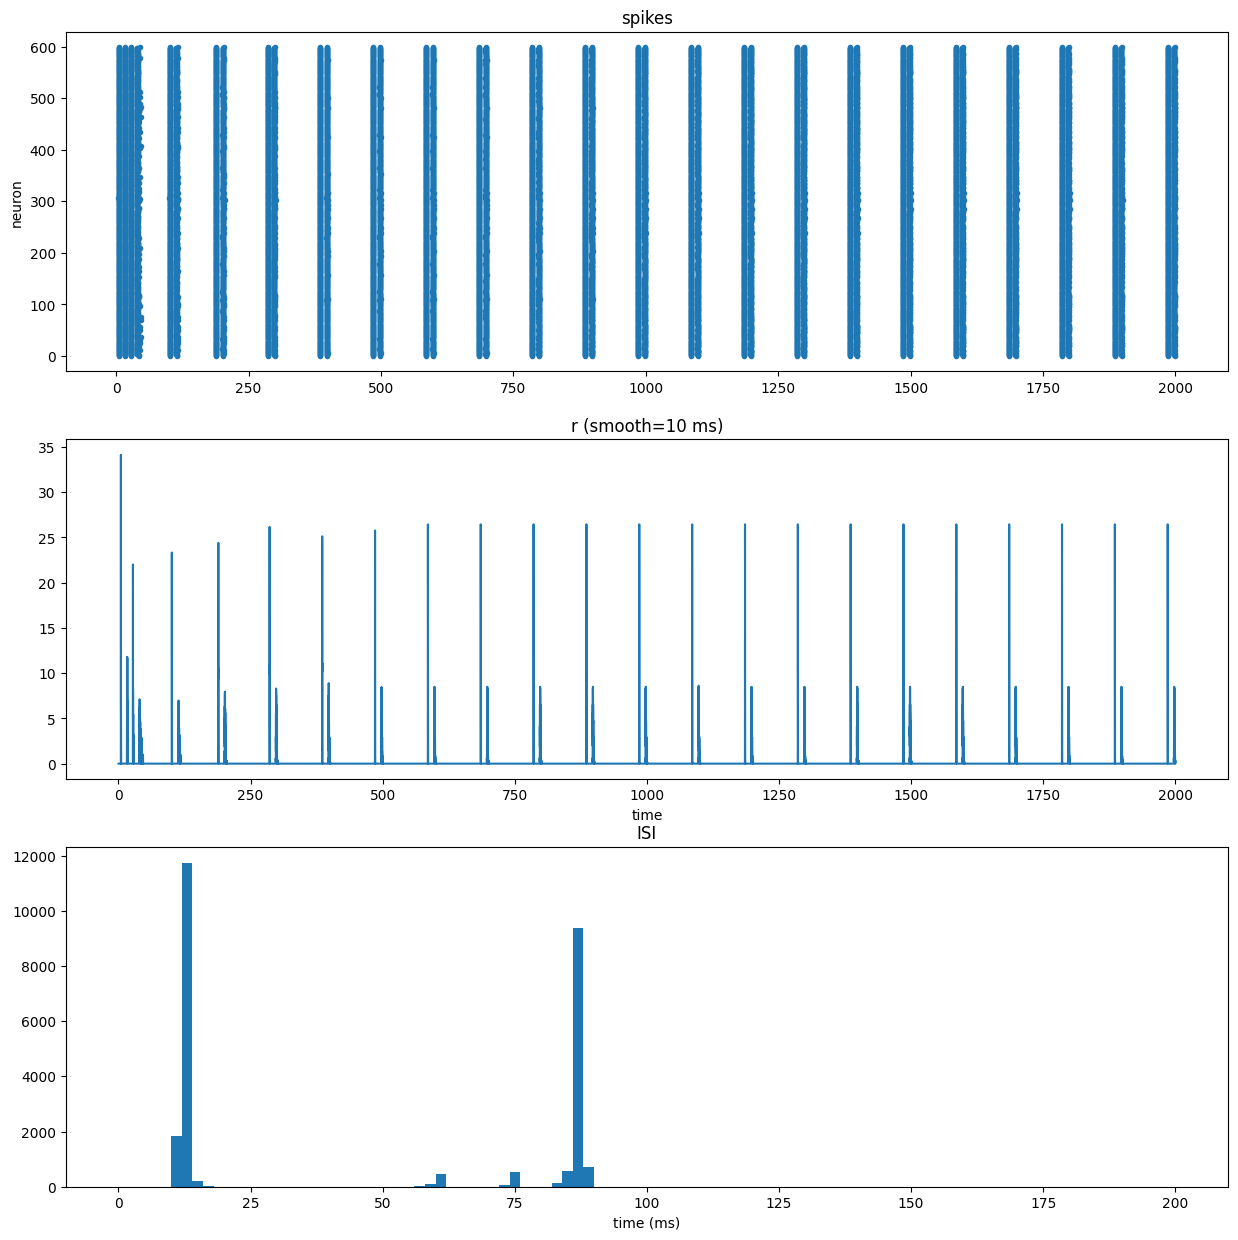

In [11]:
spike_timesN, ranksN, spikesN, isiN, mN, figNsp, axesNsp = get_plot_spikes(mN)